# Compare classifier results across read-out conditions

Compares `results_summary.yaml` outputs from `classifier_training/experiment.py`
(see `src/python/classifier_training/README.md`) across whatever top-level model
folders you point `RESULTS_ROOT` at -- e.g. different resize field-of-view sizes
(`UNI2_448_resized`, `UNI2_896_resized`) vs. the boundary-token read-out
(`UNI2_specific_tokens_folder`, which further splits into `cell`/`nucleus`
boundary-pooled tokens -- see the top-level README's "Read-out notation" table).

Each `results_summary.yaml` is expected at:

```
{RESULTS_ROOT}/{model_name}/{correction_name}/{mapping}/{matching}/{embeddings}/{split_label}/results_summary.yaml
```

(the exact layout `experiment.py`'s `main()` writes to -- see `classifier_training/README.md`'s
"Output structure"). `split_label` is either `split_0` .. `split_N` (Leave-One-WSI-Out folds,
averaged below) or `same_wsi_split` (a random 70/15/15 split pooled across all WSIs -- a
sanity-check upper bound, *not* a LOSO fold, kept separate throughout).

Set `RESULTS_ROOT` below to wherever this folder tree lives on your machine (a local
rsync/mount of the cluster path works fine -- nothing here needs the training env vars
or a GPU).

In [1]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

## Config

`MAPPING` / `MATCHING` / `CORRECTION_NAME` only need to be set if `RESULTS_ROOT`
mixes more than one value of that path segment -- leave `None` to auto-detect (a
warning prints if more than one value is found and nothing gets filtered out).

In [2]:
# Point this at the directory holding the {model_name}/... tree, e.g. a local copy of
# /cluster/.../sc-central-tokens-code/outputs_classifier_colon (see configs/train_colon.yaml's
# output_dir) or outputs_classifier for configs/train.yaml.
RESULTS_ROOT = Path("../outputs_classifier_colon")

MAPPING = None          # e.g. "simplified_broad"
MATCHING = None         # e.g. "all_cells"
CORRECTION_NAME = None  # e.g. "raw"

# best_test_metrics / best_val_metrics keys (see trainer.py's `metric_keys`), prefixed.
METRICS = ["test_accuracy", "test_balanced_accuracy", "test_macro_f1", "test_weighted_f1"]
PRIMARY_METRIC = "test_macro_f1"

## Load results

Walks `RESULTS_ROOT` for every `results_summary.yaml`, parses the six path segments
`experiment.py` encodes into the output path, and flattens `best_config` /
`best_val_metrics` / `best_test_metrics` into one row per run. Per-class F1 goes into
its own long-format table (`per_class_df`) since class sets can differ across runs.

In [3]:
SCHEMA = ("model_name", "correction_name", "mapping", "matching", "embeddings", "split_label")


def _flatten(prefix: str, d: dict) -> dict:
    return {f"{prefix}_{k}": v for k, v in d.items()}


def load_results(root: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return (one row per run, long-format per-class F1) from every results_summary.yaml under root."""
    rows: list[dict] = []
    class_rows: list[dict] = []

    for summary_path in sorted(root.rglob("results_summary.yaml")):
        parts = summary_path.relative_to(root).parts[:-1]
        if len(parts) != len(SCHEMA):
            print(f"[skip] unexpected path depth ({len(parts)} != {len(SCHEMA)}): {summary_path}")
            continue
        meta = dict(zip(SCHEMA, parts))

        with open(summary_path) as f:
            summary = yaml.safe_load(f)

        split_label = meta["split_label"]
        is_same_wsi = split_label == "same_wsi_split"
        split_idx = None if is_same_wsi else int(split_label.removeprefix("split_"))

        rows.append({
            **meta,
            "split_idx": split_idx,
            "is_same_wsi": is_same_wsi,
            **_flatten("cfg", summary["best_config"]),
            **_flatten("val", summary["best_val_metrics"]),
            **_flatten("test", summary["best_test_metrics"]),
        })

        for eval_set in ("val", "test"):
            for class_name, f1 in summary[f"{eval_set}_per_class_f1"].items():
                class_rows.append({
                    **meta, "split_idx": split_idx, "is_same_wsi": is_same_wsi,
                    "eval_set": eval_set, "class_name": class_name, "f1": f1,
                })

    results_df = pd.DataFrame(rows)
    per_class_df = pd.DataFrame(class_rows)
    if not results_df.empty:
        results_df["condition"] = results_df["model_name"] + " | " + results_df["embeddings"]
    if not per_class_df.empty:
        per_class_df["condition"] = per_class_df["model_name"] + " | " + per_class_df["embeddings"]
    return results_df, per_class_df


results_df, per_class_df = load_results(RESULTS_ROOT)
assert not results_df.empty, f"no results_summary.yaml found under {RESULTS_ROOT.resolve()}"
print(f"Loaded {len(results_df)} runs across {results_df['model_name'].nunique()} model folder(s): "
      f"{sorted(results_df['model_name'].unique())}")
results_df.head()

Loaded 35 runs across 3 model folder(s): ['UNI2_448_resized', 'UNI2_896_resized', 'UNI2_specific_tokens_folder']


,model_name,correction_name,mapping,matching,embeddings,split_label,split_idx,is_same_wsi,cfg_dropout,cfg_hidden_dim,cfg_learning_rate,cfg_loss_weights,cfg_normalization,cfg_pca_components,val_accuracy,val_balanced_accuracy,val_loss,val_macro_f1,val_weighted_f1,test_accuracy,test_balanced_accuracy,test_loss,test_macro_f1,test_weighted_f1,condition
0,UNI2_448_resized,raw,simplified_broad,all_cells,nucleus,same_wsi_split,NaN,True,0.2,0,0.0001,none,none,None,0.834678,0.761094,0.428810,0.771316,0.830012,0.834451,0.760884,0.427116,0.771239,0.829695,UNI2_448_resized | nucleus
1,UNI2_448_resized,raw,simplified_broad,all_cells,nucleus,split_0,0.0,False,0.2,0,0.0001,by_cell_type,none,None,0.815410,0.736633,0.672854,0.728724,0.814738,0.782051,0.758190,0.624204,0.689708,0.788018,UNI2_448_resized | nucleus
2,UNI2_448_resized,raw,simplified_broad,all_cells,nucleus,split_1,1.0,False,0.2,0,0.0001,by_cell_type,none,None,0.819947,0.778819,0.545528,0.773660,0.821981,0.782743,0.752386,0.640595,0.692361,0.790636,UNI2_448_resized | nucleus
3,UNI2_448_resized,raw,simplified_broad,all_cells,nucleus,split_2,2.0,False,0.2,0,0.0001,by_cell_type,none,None,0.818078,0.784801,0.527055,0.778835,0.822893,0.820948,0.728107,0.714030,0.741339,0.820058,UNI2_448_resized | nucleus
4,UNI2_448_resized,raw,simplified_broad,all_cells,nucleus,split_3,3.0,False,0.2,0,0.0001,none,none,None,0.782095,0.570616,0.974984,0.547057,0.749835,0.833676,0.737871,0.477728,0.747573,0.825155,UNI2_448_resized | nucleus


In [4]:
def _pick(df: pd.DataFrame, col: str, forced):
    values = df[col].unique().tolist()
    if forced is not None:
        return forced
    if len(values) > 1:
        print(f"[warning] multiple {col!r} values found {values} -- "
              f"set {col.upper()} above to filter to one; keeping all of them for now")
        return None
    return values[0]


for col, forced in (("mapping", MAPPING), ("matching", MATCHING), ("correction_name", CORRECTION_NAME)):
    picked = _pick(results_df, col, forced)
    if picked is not None:
        results_df = results_df[results_df[col] == picked]
        if not per_class_df.empty:
            per_class_df = per_class_df[per_class_df[col] == picked]

results_df[["model_name", "embeddings", "split_label", "split_idx"] + METRICS].sort_values(
    ["model_name", "embeddings", "split_idx"], na_position="last"
).reset_index(drop=True)

,model_name,embeddings,split_label,split_idx,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1
0,UNI2_448_resized,nucleus,split_0,0.0,0.782051,0.758190,0.689708,0.788018
1,UNI2_448_resized,nucleus,split_1,1.0,0.782743,0.752386,0.692361,0.790636
2,UNI2_448_resized,nucleus,split_2,2.0,0.820948,0.728107,0.741339,0.820058
3,UNI2_448_resized,nucleus,split_3,3.0,0.833676,0.737871,0.747573,0.825155
4,UNI2_448_resized,nucleus,split_4,4.0,0.824545,0.770198,0.773821,0.821725
5,UNI2_448_resized,nucleus,split_5,5.0,0.827129,0.771976,0.771407,0.822259
6,UNI2_448_resized,nucleus,split_6,6.0,0.770138,0.579066,0.541279,0.745899
7,UNI2_448_resized,nucleus,split_7,7.0,0.763752,0.574413,0.538212,0.740578
8,UNI2_448_resized,nucleus,same_wsi_split,NaN,0.834451,0.760884,0.771239,0.829695
9,UNI2_896_resized,nucleus,split_0,0.0,0.770236,0.743927,0.678433,0.776608


## Averaged across LOSO splits

`same_wsi_split` is excluded here (see intro) and handled in its own section below.

In [5]:
loso = results_df[~results_df["is_same_wsi"]]

agg_mean = loso.groupby(["model_name", "embeddings"])[METRICS].mean()
agg_std = loso.groupby(["model_name", "embeddings"])[METRICS].std()
n_splits = loso.groupby(["model_name", "embeddings"]).size().rename("n_splits")

summary_table = agg_mean.round(4).join(n_splits)
summary_table

test_accuracy  test_balanced_accuracy  test_macro_f1  test_weighted_f1  n_splits
model_name                  embeddings                                                                                  
UNI2_448_resized            nucleus            0.8006                  0.7090          0.687            0.7943         8
UNI2_896_resized            nucleus            0.7894                  0.6888          0.670            0.7814         8
UNI2_specific_tokens_folder cell               0.8056                  0.7050          0.687            0.7978         8
                            nucleus            0.8065                  0.6992          0.687            0.7974         7

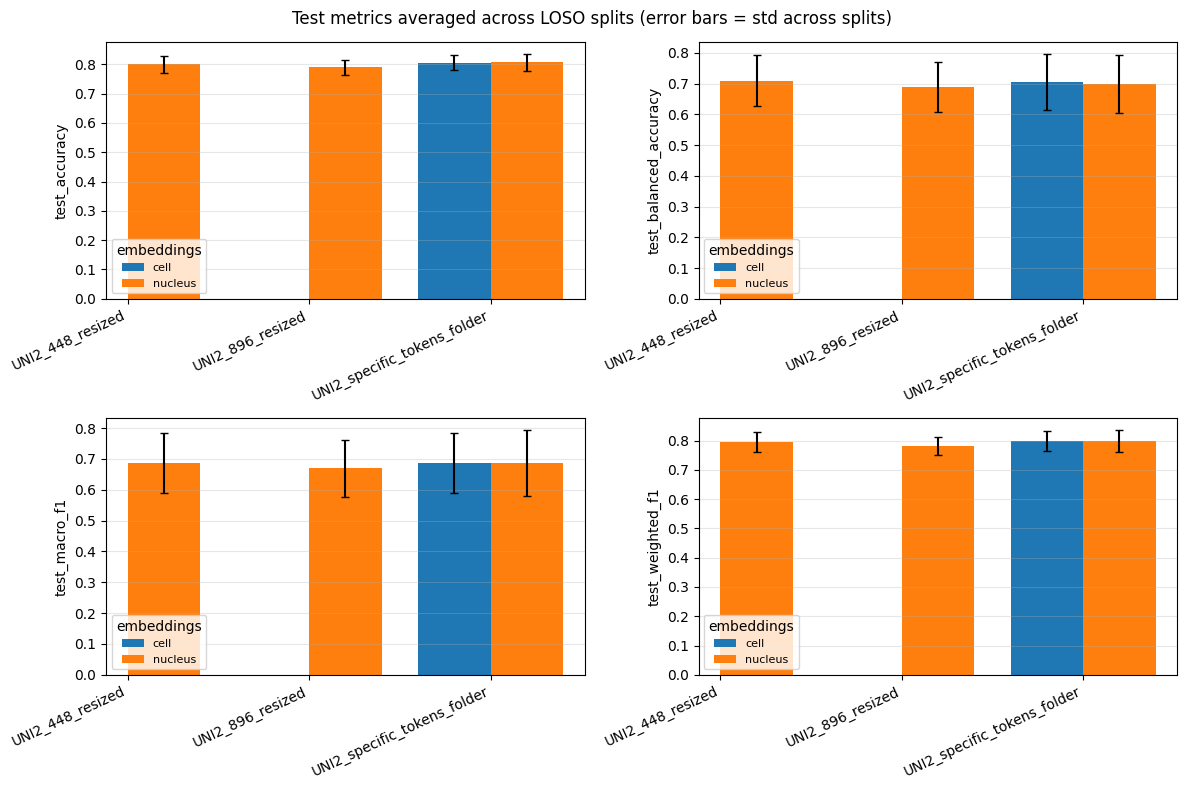

In [6]:
def _metric_grid(n_metrics: int, figsize_per=(6, 4)):
    ncols = 2 if n_metrics > 1 else 1
    nrows = math.ceil(n_metrics / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per[0] * ncols, figsize_per[1] * nrows))
    axes = np.atleast_1d(axes).flatten()
    for ax in axes[n_metrics:]:
        ax.axis("off")
    return fig, axes


def grouped_bar(ax, mean_pivot: pd.DataFrame, std_pivot: pd.DataFrame, ylabel: str):
    conditions = mean_pivot.index.tolist()
    hues = mean_pivot.columns.tolist()
    x = np.arange(len(conditions))
    width = 0.8 / max(len(hues), 1)
    for i, hue in enumerate(hues):
        means = mean_pivot[hue].values
        stds = std_pivot[hue].reindex(mean_pivot.index).fillna(0).values if hue in std_pivot else np.zeros_like(means)
        ax.bar(x + i * width - 0.4 + width / 2, means, width=width, yerr=stds, capsize=3, label=str(hue))
    ax.set_xticks(x)
    ax.set_xticklabels(conditions, rotation=25, ha="right")
    ax.set_ylabel(ylabel)
    ax.legend(title="embeddings", fontsize=8)
    ax.grid(axis="y", alpha=0.3)


fig, axes = _metric_grid(len(METRICS))
for ax, metric in zip(axes, METRICS):
    mean_pivot = loso.pivot_table(index="model_name", columns="embeddings", values=metric, aggfunc="mean")
    std_pivot = loso.pivot_table(index="model_name", columns="embeddings", values=metric, aggfunc="std")
    grouped_bar(ax, mean_pivot, std_pivot, metric)
fig.suptitle("Test metrics averaged across LOSO splits (error bars = std across splits)")
fig.tight_layout()
plt.show()

## Every LOSO split individually

Same metrics, unaveraged -- one point per `split_idx` per condition, to see
fold-to-fold variability the averages above hide.

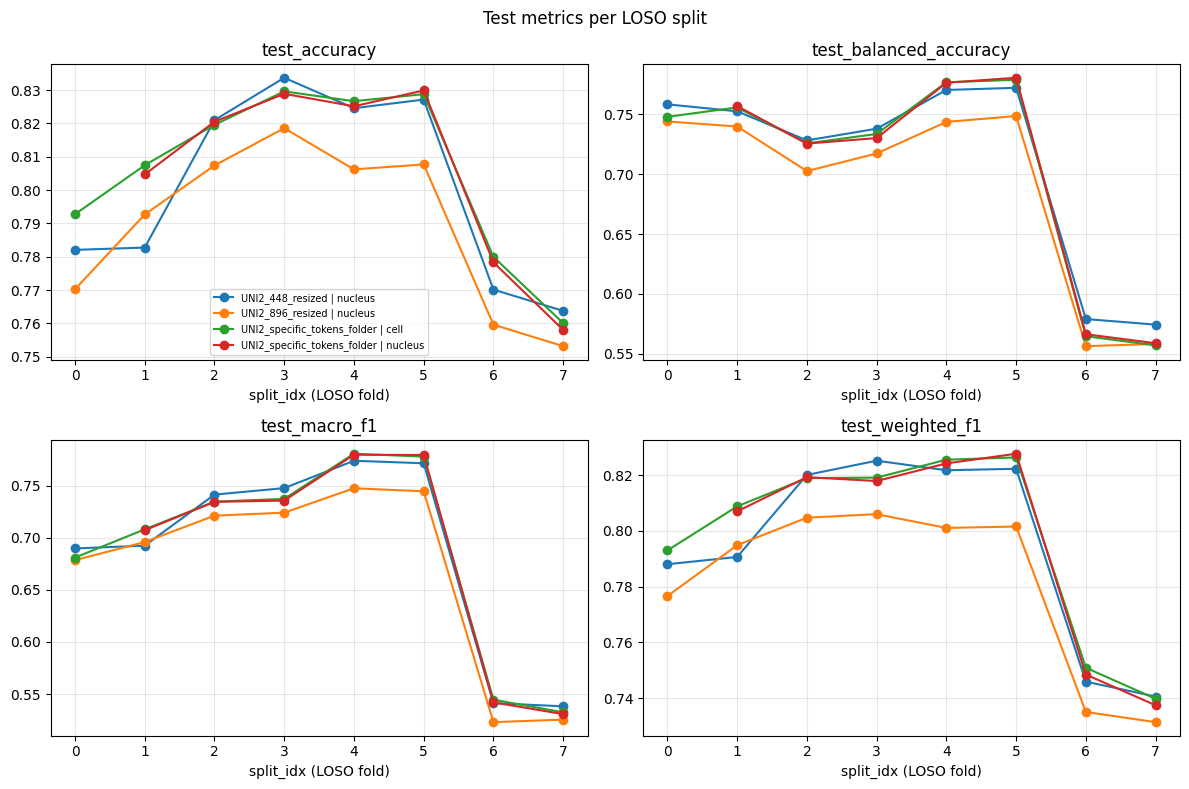

In [7]:
fig, axes = _metric_grid(len(METRICS))
for ax, metric in zip(axes, METRICS):
    pivot = loso.pivot_table(index="split_idx", columns="condition", values=metric)
    for condition in pivot.columns:
        ax.plot(pivot.index, pivot[condition], marker="o", label=condition)
    ax.set_title(metric)
    ax.set_xlabel("split_idx (LOSO fold)")
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=7, loc="best")
fig.suptitle("Test metrics per LOSO split")
fig.tight_layout()
plt.show()

In [8]:
# Full per-split table, for reference/export.
loso.sort_values(["model_name", "embeddings", "split_idx"])[
    ["model_name", "embeddings", "split_idx"] + METRICS
].reset_index(drop=True)

,model_name,embeddings,split_idx,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1
0,UNI2_448_resized,nucleus,0.0,0.782051,0.758190,0.689708,0.788018
1,UNI2_448_resized,nucleus,1.0,0.782743,0.752386,0.692361,0.790636
2,UNI2_448_resized,nucleus,2.0,0.820948,0.728107,0.741339,0.820058
3,UNI2_448_resized,nucleus,3.0,0.833676,0.737871,0.747573,0.825155
4,UNI2_448_resized,nucleus,4.0,0.824545,0.770198,0.773821,0.821725
5,UNI2_448_resized,nucleus,5.0,0.827129,0.771976,0.771407,0.822259
6,UNI2_448_resized,nucleus,6.0,0.770138,0.579066,0.541279,0.745899
7,UNI2_448_resized,nucleus,7.0,0.763752,0.574413,0.538212,0.740578
8,UNI2_896_resized,nucleus,0.0,0.770236,0.743927,0.678433,0.776608
9,UNI2_896_resized,nucleus,1.0,0.792663,0.739707,0.695831,0.794845


## `same_wsi_split` -- upper-bound sanity check

Random 70/15/15 split pooled across all WSIs in one condition -- no cross-WSI batch
effect to generalize across, so this is expected to score at or above the LOSO mean.
A condition where it *doesn't* is worth a second look.

In [9]:
loso_mean = loso.groupby(["model_name", "embeddings"])[METRICS].mean()
same_wsi = results_df[results_df["is_same_wsi"]].set_index(["model_name", "embeddings"])[METRICS]
same_wsi = same_wsi.reindex(loso_mean.index)

compare = loso_mean.add_suffix("_loso_mean").join(same_wsi.add_suffix("_same_wsi"))
compare = compare[[c for pair in zip([f"{m}_loso_mean" for m in METRICS], [f"{m}_same_wsi" for m in METRICS]) for c in pair]]
compare.round(4)

test_accuracy_loso_mean  test_accuracy_same_wsi  test_balanced_accuracy_loso_mean  test_balanced_accuracy_same_wsi  \
model_name                  embeddings                                                                                                                       
UNI2_448_resized            nucleus                      0.8006                  0.8345                            0.7090                           0.7609   
UNI2_896_resized            nucleus                      0.7894                  0.8262                            0.6888                           0.7461   
UNI2_specific_tokens_folder cell                         0.8056                  0.8335                            0.7050                           0.7598   
                            nucleus                      0.8065                  0.8344                            0.6992                           0.7616   

                                        test_macro_f1_loso_mean  test_macro_f1_same_wsi  test_weighted_f1_loso_mean  test_weighted_f1_same_wsi  
model_name                  embeddings                                                                                                          
UNI2_448_resized            nucleus                       0.687                  0.7712                      0.7943                     0.8297  
UNI2_896_resized            nucleus                       0.670                  0.7566                      0.7814                     0.8198  
UNI2_specific_tokens_folder cell                          0.687                  0.7696                      0.7978                     0.8289  
                            nucleus                       0.687                  0.7716                      0.7974                     0.8301

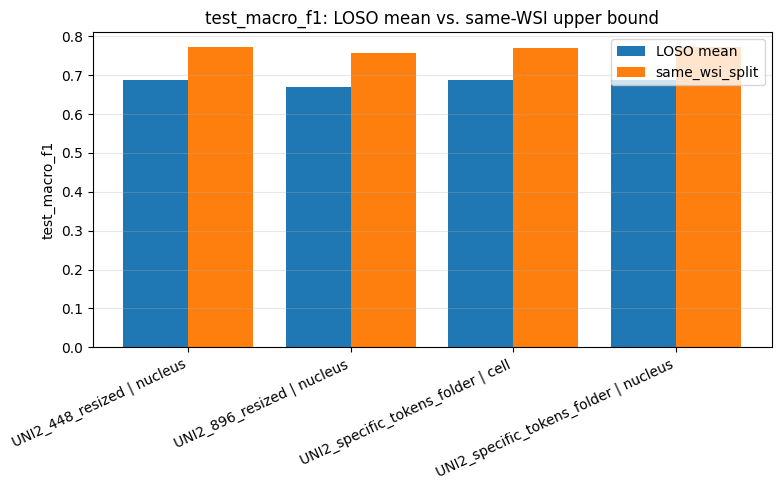

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
conditions = [f"{m} | {e}" for m, e in loso_mean.index]
x = np.arange(len(conditions))
ax.bar(x - 0.2, loso_mean[PRIMARY_METRIC].values, width=0.4, label="LOSO mean")
ax.bar(x + 0.2, same_wsi[PRIMARY_METRIC].values, width=0.4, label="same_wsi_split")
ax.set_xticks(x)
ax.set_xticklabels(conditions, rotation=25, ha="right")
ax.set_ylabel(PRIMARY_METRIC)
ax.set_title(f"{PRIMARY_METRIC}: LOSO mean vs. same-WSI upper bound")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## Per-class F1

Mean test-set per-class F1 across LOSO splits, one row per condition.

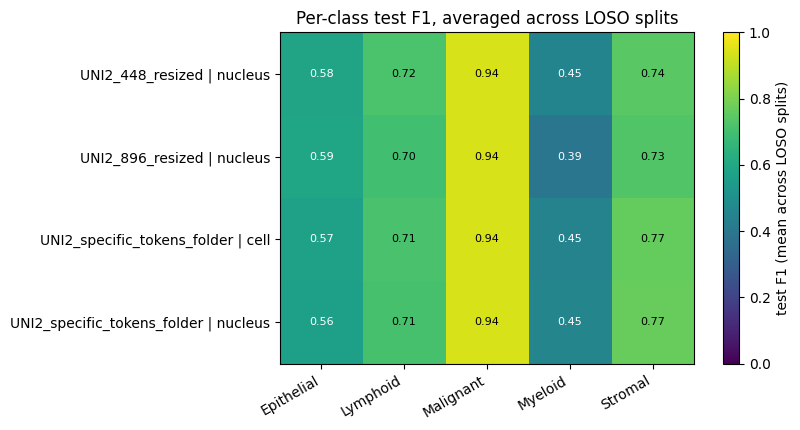

class_name,Epithelial,Lymphoid,Malignant,Myeloid,Stromal
condition,,,,,
UNI2_448_resized | nucleus,0.5835,0.7175,0.9410,0.4493,0.7435
UNI2_896_resized | nucleus,0.5924,0.6959,0.9389,0.3934,0.7293
UNI2_specific_tokens_folder | cell,0.5708,0.7128,0.9403,0.4457,0.7654
UNI2_specific_tokens_folder | nucleus,0.5640,0.7101,0.9401,0.4532,0.7676


In [11]:
test_class = per_class_df[(per_class_df["eval_set"] == "test") & (~per_class_df["is_same_wsi"])]
heat = test_class.pivot_table(index="condition", columns="class_name", values="f1", aggfunc="mean")

fig, ax = plt.subplots(figsize=(1.2 * len(heat.columns) + 2, 0.6 * len(heat.index) + 2))
im = ax.imshow(heat.values, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=30, ha="right")
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    color="white" if val < 0.6 else "black", fontsize=8)
fig.colorbar(im, ax=ax, label="test F1 (mean across LOSO splits)")
ax.set_title("Per-class test F1, averaged across LOSO splits")
fig.tight_layout()
plt.show()
heat.round(4)